## 1. Importando as bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para manipulação dos dados, visualização gráfica, pré-processamento e treinamento dos modelos de Machine Learning.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 2. Carregando o dataset

Nesta etapa o dataset é carregado para análise e manipulação dos dados clínicos.

In [ ]:
healthcare_df = pd.read_csv("healthcare_dataset.csv", sep=",")
original_df = healthcare_df
healthcare_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 3. Exploração Inicial dos Dados

Nesta etapa é realizada uma análise inicial do dataset para entender a estrutura dos dados, tipos das variáveis e possíveis valores ausentes.

In [ ]:
print('Informações do DataFrame:')
healthcare_df.info()

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), ob

In [ ]:
healthcare_df.describe(include='all')

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


In [ ]:
healthcare_df.isnull().sum()


,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [ ]:
print('Valores ausentes por coluna:')
valores_ausentes = healthcare_df.isnull().sum()
display(valores_ausentes[valores_ausentes > 0])

Valores ausentes por coluna:


,0


In [ ]:
healthcare_df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

## 3. Remoção de Colunas Irrelevantes

Nesta etapa foram removidas colunas que não possuem relevância direta para a previsão dos desfechos clínicos.

In [ ]:
healthcare_df = healthcare_df.drop(columns=[
    'Name',
    'Doctor',
    'Hospital',
    'Insurance Provider',
    'Room Number',
    'Date of Admission',
    'Discharge Date'
], errors='ignore')

healthcare_df.head()

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,18856.281306,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,33643.327287,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,27955.096079,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,37909.782410,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,14238.317814,Urgent,Penicillin,Abnormal


In [ ]:
healthcare_df['Test Results'].value_counts()

,count
Test Results,
Abnormal,18627
Normal,18517
Inconclusive,18356


## 4. Célula Clinical Outcome

Nesta etapa foi criada uma variável de desfecho clínico baseada em fatores de risco dos pacientes, simulando possíveis complicações hospitalares.

In [ ]:
def definir_desfecho(row):

    score = 0

    if row['Age'] >= 60:
        score += 1

    if row['Admission Type'] == 'Emergency':
        score += 1

    if row['Test Results'] == 'Abnormal':
        score += 1

    if row['Billing Amount'] > 30000:
        score += 1

    if row['Medical Condition'] in [
        'Cancer',
        'Diabetes',
        'Heart Disease'
    ]:
        score += 1

    if score >= 4:
        return 'Complication'

    elif score >= 2:
        return 'Readmitted'

    else:
        return 'Stable'

## 5.Criação e Análise do Desfecho Clínico

Nesta etapa foi criada a variável alvo do projeto, analisada a distribuição das classes e removida uma variável que poderia causar vazamento de dados.

In [ ]:
healthcare_df['Clinical Outcome'] = healthcare_df.apply(
    definir_desfecho,
    axis=1
)

print(
    healthcare_df['Clinical Outcome'].value_counts()
)

healthcare_df = healthcare_df.drop(
    columns=['Test Results']
)

Clinical Outcome
Readmitted      29365
Stable          22919
Complication     3216
Name: count, dtype: int64


## 7. Separação das Variáveis

Nesta etapa foram separadas as variáveis de entrada (X) e a variável alvo (y) utilizada no treinamento dos modelos.

In [ ]:
X = healthcare_df.drop(columns='Clinical Outcome', axis=1)
y = healthcare_df['Clinical Outcome']

## 8. Aplicando LabelEncoder

Nesta etapa algumas variáveis categóricas foram transformadas em valores numéricos para possibilitar o treinamento dos modelos.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
X['Gender'] = label.fit_transform(X['Gender'])

label = LabelEncoder()
mapping = {'Elective' : 0, 'Urgent' : 1, 'Emergency' : 2}
X['Admission Type'] = X['Admission Type'].map(mapping)

In [ ]:
X

,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication
0,30,1,B-,Cancer,18856.281306,1,Paracetamol
1,62,1,A+,Obesity,33643.327287,2,Ibuprofen
2,76,0,A-,Obesity,27955.096079,2,Aspirin
3,28,0,O+,Diabetes,37909.782410,0,Ibuprofen
4,43,0,AB+,Cancer,14238.317814,1,Penicillin
...,...,...,...,...,...,...,...
55495,42,0,O+,Asthma,2650.714952,0,Penicillin
55496,61,0,AB-,Obesity,31457.797307,0,Aspirin
55497,38,0,B+,Hypertension,27620.764717,1,Ibuprofen
55498,43,1,O-,Arthritis,32451.092358,0,Ibuprofen


## 9. Aplicando OneHotEncoder

Nesta etapa foi aplicado OneHotEncoder para transformar variáveis categóricas em colunas numéricas binárias.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

colunas_OneHotEncoder = ['Blood Type', 'Medical Condition', 'Medication']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(X[colunas_OneHotEncoder])
encoded_colunas = encoder.get_feature_names_out(colunas_OneHotEncoder)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_colunas,
    index=X.index
)

X = X.drop(columns=colunas_OneHotEncoder)
X = pd.concat([X, encoded_df], axis=1)
X.head()

,Age,Gender,Billing Amount,Admission Type,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,...,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,30,1,18856.281306,1,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,62,1,33643.327287,2,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,76,0,27955.096079,2,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,28,0,37909.782410,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,43,0,14238.317814,1,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
healthcare_df['Blood Type'].unique()

array(['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-'], dtype=object)

In [ ]:
X

,Age,Gender,Billing Amount,Admission Type,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,...,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,30,1,18856.281306,1,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,62,1,33643.327287,2,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,76,0,27955.096079,2,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,28,0,37909.782410,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,43,0,14238.317814,1,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,0,2650.714952,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55496,61,0,31457.797307,0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
55497,38,0,27620.764717,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
55498,43,1,32451.092358,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 10. Visualização da Distribuição das Classes

In [ ]:
print(y.value_counts())
print("")
print(y.value_counts(normalize=True) * 100)

Clinical Outcome
Readmitted      29365
Stable          22919
Complication     3216
Name: count, dtype: int64

Clinical Outcome
Readmitted      52.909910
Stable          41.295495
Complication     5.794595
Name: proportion, dtype: float64


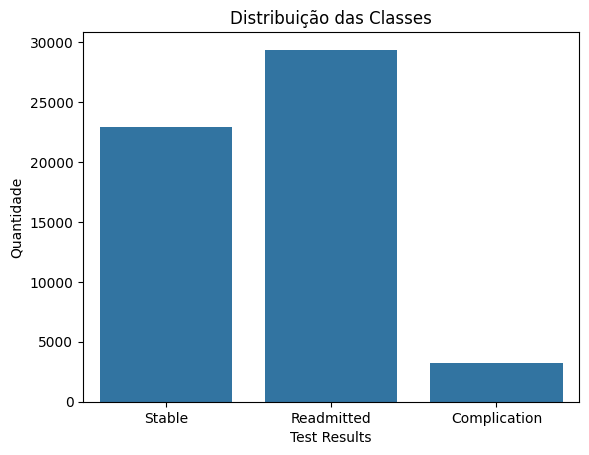

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title('Distribuição das Classes')
plt.xlabel('Test Results')
plt.ylabel('Quantidade')

plt.savefig('antes_balanceamento.png')
plt.show()

# 11. Treino e Teste

Nesta etapa os dados foram divididos em conjuntos de treino e teste para treinamento e avaliação dos modelos.

In [ ]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino: ", X_treino.shape)
print("Teste: ", X_teste.shape)

Treino:  (38850, 23)
Teste:  (16650, 23)



## 12. Balanceamento das Classes com SMOTE

Nesta etapa foi aplicada a técnica SMOTE para balancear as classes do conjunto de treino e reduzir problemas causados pelo desbalanceamento dos dados.


Distribuição das classes após o SMOTE:
Clinical Outcome
Stable          20556
Readmitted      20556
Complication    20556
Name: count, dtype: int64


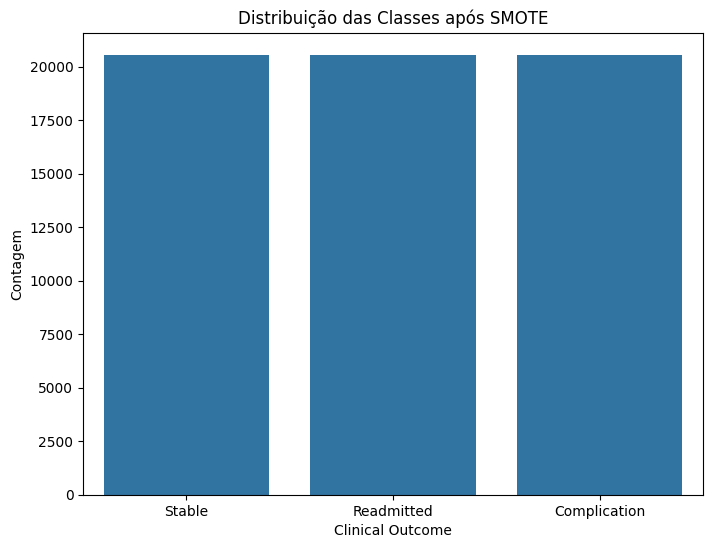

In [ ]:
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

smote = SMOTE(random_state=42)

X_treino_resampled, y_treino_resampled = smote.fit_resample(X_treino, y_treino)

print("Distribuição das classes após o SMOTE:")
print(y_treino_resampled.value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x=y_treino_resampled)
plt.title('Distribuição das Classes após SMOTE')
plt.xlabel('Clinical Outcome')
plt.ylabel('Contagem')

plt.savefig('depois_balanceamento.png')
plt.show()

## 13. Normalização dos Dados

Nesta etapa os dados numéricos foram normalizados utilizando StandardScaler para melhorar o desempenho dos modelos de Machine Learning.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colunas_numericas = [
    'Age',
    'Billing Amount'
]

X_treino_resampled[colunas_numericas] = scaler.fit_transform(
    X_treino_resampled[colunas_numericas]
)

X_teste[colunas_numericas] = scaler.transform(
    X_teste[colunas_numericas]
)

##14. Treinamento da Regressão Logística

Nesta etapa foi treinado o modelo de Regressão Logística para classificação dos desfechos clínicos.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

modelo_logistico = LogisticRegression(
    max_iter=100,
    class_weight='balanced',
    random_state=42
    )

modelo_logistico.fit(X_treino_resampled, y_treino_resampled)


LogisticRegression(class_weight='balanced', random_state=42)

##15. Interpretação da Regressão Logística

Nesta etapa foram analisados os coeficientes da Regressão Logística para identificar as variáveis mais influentes nas previsões do modelo.

In [ ]:
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
})

coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
).head(10)

,Feature,Coeficiente
15,Medical Condition_Diabetes,2.037497
14,Medical Condition_Cancer,1.999854
3,Admission Type,1.672150
0,Age,1.606192
2,Billing Amount,1.541316
7,Blood Type_AB-,-0.178678
5,Blood Type_A-,-0.193570
4,Blood Type_A+,-0.203594
10,Blood Type_O+,-0.268255
8,Blood Type_B+,-0.268445


## 16. Fazendo Previsões

In [ ]:
previsoes_log = modelo_logistico.predict(X_teste)

resultado_log = pd.DataFrame({
    "classe_real": y_teste.values,
    "classe_prevista": previsoes_log,
})

display(resultado_log.head(20))

,classe_real,classe_prevista
0,Stable,Stable
1,Readmitted,Complication
2,Readmitted,Stable
3,Readmitted,Readmitted
4,Stable,Stable
5,Stable,Stable
6,Stable,Stable
7,Readmitted,Stable
8,Stable,Stable
9,Readmitted,Readmitted


In [ ]:
probabilidades_log = modelo_logistico.predict_proba(X_teste)

prob_df = pd.DataFrame(
    probabilidades_log,
    columns=modelo_logistico.classes_
)

display(prob_df.head())

,Complication,Readmitted,Stable
0,0.001322,0.245476,0.753202
1,0.686983,0.306733,0.006285
2,0.004584,0.371771,0.623646
3,0.329140,0.621377,0.049483
4,0.000062,0.089049,0.910890


##17. Avaliação da Regressão Logística

Nesta etapa foram calculadas métricas de desempenho para avaliar a capacidade da Regressão Logística em prever os desfechos clínicos.

In [ ]:
acuracia_rl = accuracy_score(y_teste, previsoes_log)
precisao_rl = precision_score(y_teste, previsoes_log, average='weighted')
recall_rl = recall_score(y_teste, previsoes_log, average='weighted')
f1_rl = f1_score(y_teste, previsoes_log, average='weighted')

cm = confusion_matrix(
    y_teste,
    previsoes_log
)

specificities = []

for i in range(len(cm)):
  tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
  fp = np.sum(cm[:,i]) - cm[i,i]

  specificity = tn / (tn + fp)
  specificities.append(specificity)

specificity_media = np.mean(specificities)

print("Métricas - Regressão Logística")
print(f"Acurácia : {acuracia_rl:.4f}")
print(f"Precisão : {precisao_rl:.4f}")
print(f"Recall   : {recall_rl:.4f}")
print(f"F1-score : {f1_rl:.4f}")
print("Especificidade Média:", specificity_media)

Métricas - Regressão Logística
Acurácia : 0.7145
Precisão : 0.7526
Recall   : 0.7145
F1-score : 0.7230
Especificidade Média: 0.8452843068691164


## 18. Matriz de Confusão Regressão Logística

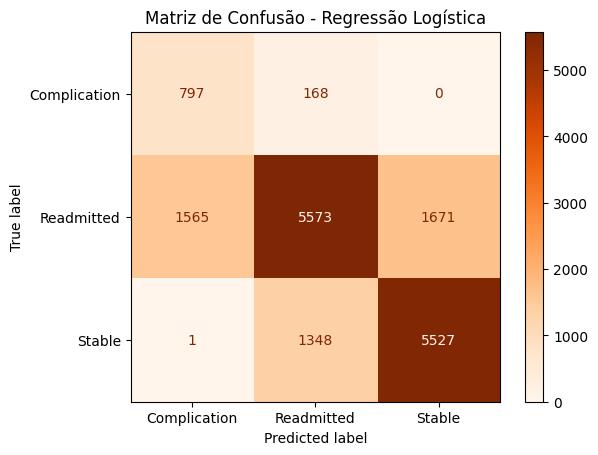

Relatório de classificação:
              precision    recall  f1-score   support

Complication       0.34      0.83      0.48       965
  Readmitted       0.79      0.63      0.70      8809
      Stable       0.77      0.80      0.79      6876

    accuracy                           0.71     16650
   macro avg       0.63      0.75      0.66     16650
weighted avg       0.75      0.71      0.72     16650



In [ ]:
matrziConfuso_log = confusion_matrix(y_teste, previsoes_log)

disp = ConfusionMatrixDisplay(confusion_matrix=matrziConfuso_log, display_labels=modelo_logistico.classes_)
disp.plot(cmap="Oranges")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

print("Relatório de classificação:")
print(classification_report(y_teste, previsoes_log, target_names=modelo_logistico.classes_))


##19. Curva ROC e AUC

Nesta etapa foi calculada a Curva ROC e a métrica AUC para avaliar a capacidade discriminativa da Regressão Logística.

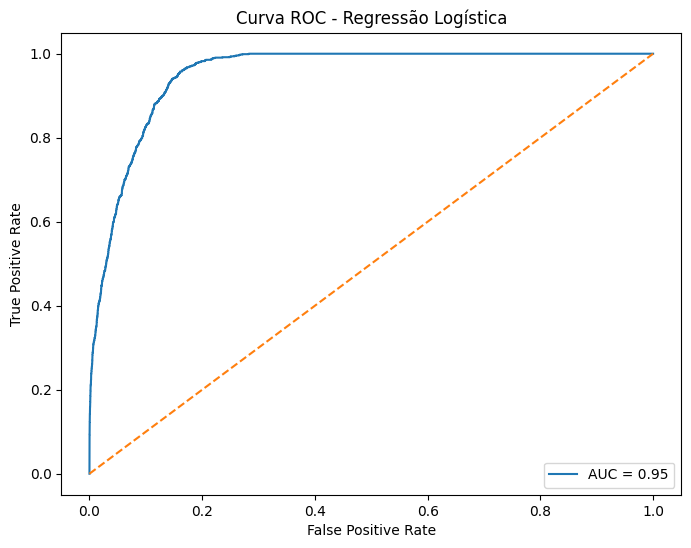

AUC: 0.9517496172211661


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_binario = label_binarize(
    y_teste,
    classes=modelo_logistico.classes_
)

probabilidades_rl = modelo_logistico.predict_proba(
    X_teste
)

fpr, tpr, _ = roc_curve(
    y_binario[:,0],
    probabilidades_rl[:,0]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('Curva ROC - Regressão Logística')

plt.legend()

plt.show()

print("AUC:", roc_auc)

##20. Net Benefit

Nesta etapa foi calculado o Net Benefit para avaliar o benefício clínico do modelo considerando acertos e falsos positivos.

In [ ]:
threshold = 0.5

preds_log = (
    probabilidades_log[:,0] >= threshold
).astype(int)

tp_log = np.sum(
    (preds_log == 1) &
    (y_binario[:,0] == 1)
)

fp_log = np.sum(
    (preds_log == 1) &
    (y_binario[:,0] == 0)
)

n = len(y_binario)

net_benefit_log = (
    (tp_log / n)
    -
    (fp_log / n)
    *
    (threshold / (1-threshold))
)

print("Net Benefit RL:", net_benefit_log)

Net Benefit RL: -0.04468468468468468


# 21. Treinando Random Foreste

Nesta etapa foi treinado o modelo de Regressão Logística para classificação dos desfechos clínicos.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

modelo_rf.fit(X_treino_resampled, y_treino_resampled)


RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

## 22. Interpetação do Random Forest

Nesta etapa foram analisados os coeficientes do Random Forest para identificar as variáveis mais influentes nas previsões do modelo.

In [ ]:
importances = pd.DataFrame({
    'Feature':X.columns,
    'Importance': modelo_rf.feature_importances_
})

importances = importances.sort_values(
    by='Importance',
    ascending=False
)

display(importances.head(10))

,Feature,Importance
0,Age,0.201400
2,Billing Amount,0.196153
3,Admission Type,0.140691
15,Medical Condition_Diabetes,0.134418
14,Medical Condition_Cancer,0.125838
12,Medical Condition_Arthritis,0.030276
13,Medical Condition_Asthma,0.028397
17,Medical Condition_Obesity,0.026940
16,Medical Condition_Hypertension,0.025008
21,Medication_Paracetamol,0.014874


## 23. Fazendo previsões

Nesta etapa foram calculadas métricas de desempenho para avaliar a capacidade do Random Forest em prever os desfechos clínicos.

In [ ]:
previsoes_rf = modelo_rf.predict(X_teste)

resultado_rf = pd.DataFrame({
    "classe_real": y_teste.values,
    "classe_prevista": previsoes_rf,
})

display(resultado_rf.head(20))

,classe_real,classe_prevista
0,Stable,Stable
1,Readmitted,Readmitted
2,Readmitted,Readmitted
3,Readmitted,Readmitted
4,Stable,Stable
5,Stable,Stable
6,Stable,Stable
7,Readmitted,Stable
8,Stable,Stable
9,Readmitted,Readmitted


In [ ]:
probabilidades_rf = modelo_rf.predict_proba(X_teste)

prob_df = pd.DataFrame(
    probabilidades_rf,
    columns=modelo_rf.classes_
)

display(prob_df.head())

,Complication,Readmitted,Stable
0,0.010329,0.454256,0.535415
1,0.424369,0.560718,0.014913
2,0.173653,0.682670,0.143677
3,0.070869,0.782266,0.146865
4,0.007028,0.352096,0.640876


## 24. Métricas do Random Forest

Nesta etapa foram calculadas métricas de desempenho para avaliar a capacidade do Random Forestem prever os desfechos clínicos.

In [ ]:
acuracia_rf = accuracy_score(y_teste, previsoes_rf)
precisao_rf = precision_score(y_teste, previsoes_rf, average='weighted')
recall_rf = recall_score(y_teste, previsoes_rf, average='weighted')
f1_rf = f1_score(y_teste, previsoes_rf, average='weighted')

cm = confusion_matrix(
    y_teste,
    previsoes_rf
)

specificities = []

for i in range(len(cm)):
  tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
  fp = np.sum(cm[:,i]) - cm[i,i]

  specificity = tn / (tn + fp)
  specificities.append(specificity)

specificity_media = np.mean(specificities)
print("Métricas - Random Forest")
print(f"Acurácia : {acuracia_rf:.4f}")
print(f"Precisão : {precisao_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print("Especificidade Média:", specificity_media)

Métricas - Random Forest
Acurácia : 0.8126
Precisão : 0.8442
Recall   : 0.8126
F1-score : 0.8104
Especificidade Média: 0.8992211970764853


## 25. Matriz de Confusão Random Forest

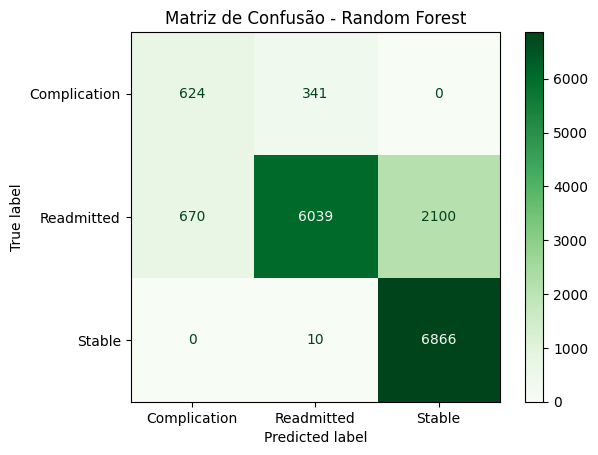

Relatório de classificação:
              precision    recall  f1-score   support

Complication       0.48      0.65      0.55       965
  Readmitted       0.95      0.69      0.79      8809
      Stable       0.77      1.00      0.87      6876

    accuracy                           0.81     16650
   macro avg       0.73      0.78      0.74     16650
weighted avg       0.84      0.81      0.81     16650



In [ ]:
matrizConfuso_rf = confusion_matrix(y_teste, previsoes_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=matrizConfuso_rf, display_labels=modelo_rf.classes_)
disp.plot(cmap="Greens")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

print("Relatório de classificação:")

print(classification_report(
        y_teste,
        previsoes_rf,
        target_names=modelo_rf.classes_
    )
)

##26. Curva de ROC + AUV

Nesta etapa foi calculada a Curva ROC e a métrica AUC para avaliar a capacidade discriminativa do Random Forest.

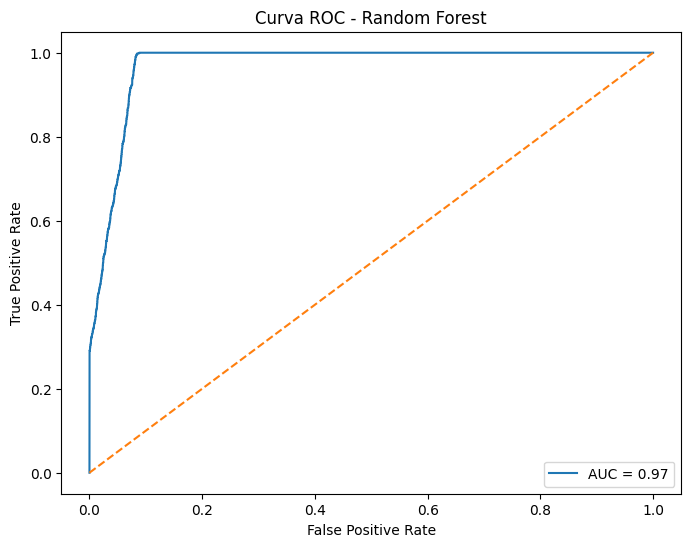

AUC: 0.9699767277075718


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_binario = label_binarize(
    y_teste,
    classes=modelo_rf.classes_
)

probabilidades_rf = modelo_rf.predict_proba(
    X_teste
)

fpr, tpr, _ = roc_curve(
    y_binario[:,0],
    probabilidades_rf[:,0]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('Curva ROC - Random Forest')

plt.legend()

plt.show()

print("AUC:", roc_auc)

##27. Net Benefit

Nesta etapa foi calculado o Net Benefit para avaliar o benefício clínico do modelo considerando acertos e falsos positivos.

In [ ]:
preds_rf = (
    probabilidades_rf[:,0] >= threshold
).astype(int)

tp_rf = np.sum(
    (preds_rf == 1) &
    (y_binario[:,0] == 1)
)

fp_rf = np.sum(
    (preds_rf == 1) &
    (y_binario[:,0] == 0)
)

net_benefit_rf = (
    (tp_rf / n)
    -
    (fp_rf / n)
    *
    (threshold / (1-threshold))
)

print("Net Benefit RF:", net_benefit_rf)

Net Benefit RF: -0.0007807807807807821


# Comparação entre os Modelos (Regrssão Logística e Random Forest)

Nesta etapa foi realizada a comparação entre Regressão Logística e Random Forest utilizando métricas de desempenho e avaliação clínica.

In [ ]:
print('=-=-=-=-=-= COPARAÇÃO ENTRE OS MODELOS DE REGRESSÃO LOGISTICA E RANDOM FOREST =-=-=-=-=-=')
print('')

comparacao = pd.DataFrame({

    'Métrica': [
        'Acurácia',
        'Precisão',
        'Sensibilidade',
        'Especificidade',
        'F1-Score',
        'AUC',
        'Net Benefit'
    ],

    'Regressão Logística': [
        acuracia_rl,
        precisao_rl,
        recall_rl,
        specificity_media,
        f1_rl,
        roc_auc,
        net_benefit_log
    ],

    'Random Forest': [
        acuracia_rf,
        precisao_rf,
        recall_rf,
        specificity_media,
        f1_rf,
        roc_auc,
        net_benefit_rf
    ]
})

display(comparacao)

=-=-=-=-=-= COPARAÇÃO ENTRE OS MODELOS DE REGRESSÃO LOGISTICA E RANDOM FOREST =-=-=-=-=-=



,Métrica,Regressão Logística,Random Forest
0,Acurácia,0.714535,0.812553
1,Precisão,0.752577,0.844204
2,Sensibilidade,0.714535,0.812553
3,Especificidade,0.899221,0.899221
4,F1-Score,0.723045,0.810417
5,AUC,0.969977,0.969977
6,Net Benefit,-0.044685,-0.000781


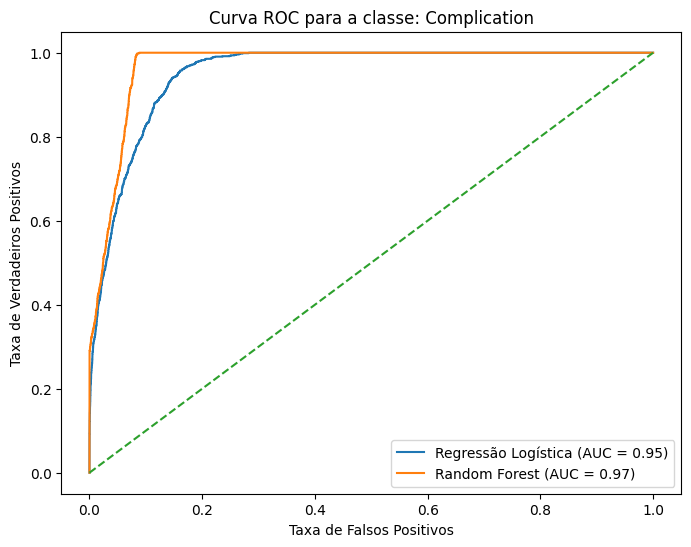

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize


y_teste_binarized = label_binarize(y_teste, classes=modelo_logistico.classes_)

y_prob_rl = modelo_logistico.predict_proba(X_teste)
y_prob_rf = modelo_rf.predict_proba(X_teste)

fpr_rl, tpr_rl, _ = roc_curve(y_teste_binarized[:, 0], y_prob_rl[:, 0])
auc_rl = auc(fpr_rl, tpr_rl)

fpr_rf, tpr_rf, _ = roc_curve(y_teste_binarized[:, 0], y_prob_rf[:, 0])
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rl,
    tpr_rl,
    label=f'Regressão Logística (AUC = {auc_rl:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.2f})'
)


plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')

plt.title('Curva ROC para a classe: ' + str(modelo_logistico.classes_[0]))

plt.legend()

plt.savefig(
    'curva_roc.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()